In [28]:
import numpy as np
import pandas as pd

In [19]:
Online_retail = pd.read_excel("Online Retail.xlsx")

In [25]:
Online_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [29]:
Online_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [30]:
Online_retail["Revenue"] = Online_retail["Quantity"] * Online_retail["UnitPrice"]

Online_retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [31]:
Order_value = Online_retail.groupby("InvoiceNo")[["Revenue"]].sum()

In [32]:
Order_value.mean().round(2)

Revenue    376.36
dtype: float64

In [33]:
Online_retail["UnitPrice"].mean().round(2)
#The Average Order Value (AOV) is approximately 376.36, indicating that each order contributes a moderate amount of revenue. Given that the average unit price is relatively low (~4.61), this suggests that customers tend to purchase multiple items per order rather than expensive individual products. This reflects a bulk-buying or multi-item purchasing behavior.

np.float64(4.61)

In [34]:
Online_retail["Month"] = Online_retail["InvoiceDate"].dt.month

Online_retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12


In [35]:
M_rev = Online_retail.groupby("Month")[["Revenue"]].sum()

M_rev

,Revenue
Month,
1,560000.260
2,498062.650
3,683267.080
4,493207.121
5,723333.510
6,691123.120
7,681300.111
8,682680.510
9,1019687.622


In [36]:
M_rev.pct_change()

,Revenue
Month,
1,NaN
2,-0.110603
3,0.371850
4,-0.278163
5,0.466592
6,-0.044530
7,-0.014213
8,0.002026
9,0.493653


<Axes: xlabel='Month'>

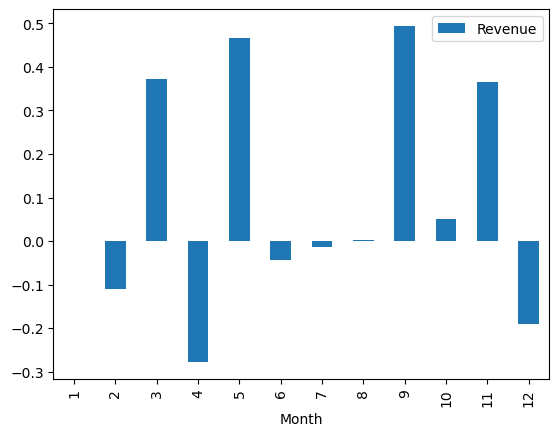

In [37]:
M_rev.pct_change().plot.bar()

# The revenue growth shows high volatility across months, with alternating periods of positive and negative growth. Significant spikes are observed in March, May, and September, indicating strong seasonal or campaign-driven performance. However, sharp declines in April and December suggest inconsistency in sustaining growth.

In [38]:
M_rev.sort_values("Revenue", ascending = False)

# This suggests that the business is highly dependent on seasonal demand. Replicating similar promotional strategies in other months could help stabilize revenue and reduce volatility.

,Revenue
Month,
11,1461756.250
12,1182625.030
10,1070704.670
9,1019687.622
5,723333.510
6,691123.120
3,683267.080
8,682680.510
7,681300.111


In [39]:
Customers = Online_retail.groupby("CustomerID")[["Revenue"]].sum()

In [40]:
Customers

,Revenue
CustomerID,
12346.0,0.00
12347.0,4310.00
12348.0,1797.24
12349.0,1757.55
12350.0,334.40
...,...
18280.0,180.60
18281.0,80.82
18282.0,176.60


In [41]:
Customers.sort_values("Revenue", ascending = False).head(5)

,Revenue
CustomerID,
14646.0,279489.02
18102.0,256438.49
17450.0,187482.17
14911.0,132572.62
12415.0,123725.45


In [42]:
Customers.sort_values("Revenue").head(5)

# As these are negative, thus we need to correct the data first so that it only shows us the revenue that is made by the lowest 5 customers

,Revenue
CustomerID,
17448.0,-4287.63
15369.0,-1592.49
14213.0,-1192.20
17603.0,-1165.30
12503.0,-1126.00


In [43]:
Online_retail = Online_retail[Online_retail["Quantity"]>0]

In [44]:
Customers = Online_retail.groupby("CustomerID")[["Revenue"]].sum()

In [45]:
Customers.sort_values("Revenue").head(5)
# Customer spending is highly skewed, with a small group of high-value customers contributing significantly to revenue, while a large number of customers have very low spend. This indicates strong potential for segmentation and targeted strategies

,Revenue
CustomerID,
13256.0,0.00
16738.0,3.75
14792.0,6.20
16454.0,6.90
17956.0,12.75


In [46]:
Customers["Bucket"] = pd.cut(Customers['Revenue'], bins = [0,1500,20000,279489.02], labels = ["Low Spenders", "Growing Customers", "High Spenders"])

In [47]:
C_segmentation = Customers["Bucket"].value_counts()

In [48]:
C_segmentation

Bucket
Low Spenders         3144
Growing Customers    1151
High Spenders          42
Name: count, dtype: int64

<Axes: xlabel='CustomerID'>

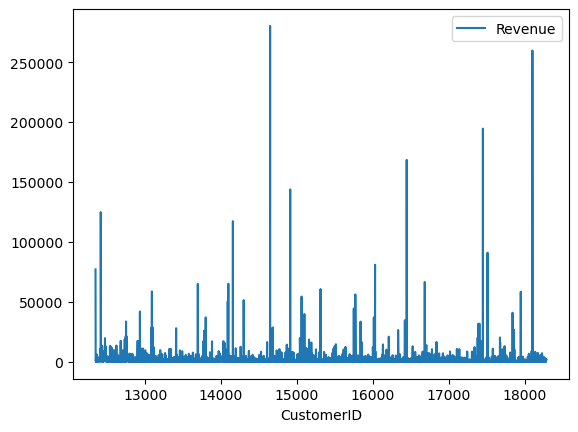

In [49]:
Customers.plot()

<Axes: xlabel='Bucket'>

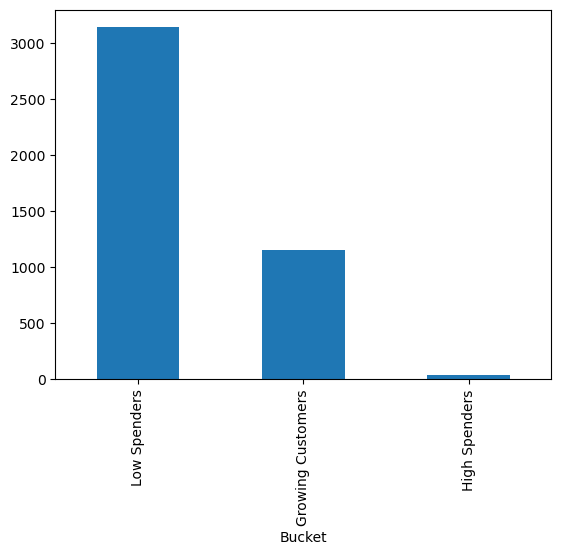

In [50]:
C_segmentation.plot.bar()

In [51]:
Orders_per_customer = Online_retail.groupby("CustomerID")[["InvoiceNo"]].nunique()

In [52]:
Orders_per_customer

,InvoiceNo
CustomerID,
12346.0,1
12347.0,7
12348.0,4
12349.0,1
12350.0,1
...,...
18280.0,1
18281.0,1
18282.0,2


In [53]:
repeat_customers = Orders_per_customer[Orders_per_customer > 1]
one_time_customers = Orders_per_customer[Orders_per_customer == 1]

In [54]:
Repeat = repeat_customers.count()

Repeat

InvoiceNo    2845
dtype: int64

In [55]:
One_time = one_time_customers.count()

One_time

InvoiceNo    1494
dtype: int64

In [56]:
Total_customers = Orders_per_customer.count()

Total_customers

InvoiceNo    4339
dtype: int64

In [57]:
repeat_percentage = (Repeat / Total_customers) * 100

In [58]:
repeat_percentage.round(2)
# The repeat customer rate is approximately 65.57%, indicating strong customer retention. This suggests that the business successfully converts a majority of its customers into repeat buyers, reducing dependency on acquiring new customers

InvoiceNo    65.57
dtype: float64

In [59]:
Type = Orders_per_customer["InvoiceNo"].apply(lambda x: 'Repeat' if x > 1 else 'One-time')

In [60]:
Type

CustomerID
12346.0    One-time
12347.0      Repeat
12348.0      Repeat
12349.0    One-time
12350.0    One-time
             ...   
18280.0    One-time
18281.0    One-time
18282.0      Repeat
18283.0      Repeat
18287.0      Repeat
Name: InvoiceNo, Length: 4339, dtype: object

In [61]:
analysis = pd.concat([Customers,Type], axis = 1)

In [62]:
analysis

,Revenue,Bucket,InvoiceNo
CustomerID,,,
12346.0,77183.60,High Spenders,One-time
12347.0,4310.00,Growing Customers,Repeat
12348.0,1797.24,Growing Customers,Repeat
12349.0,1757.55,Growing Customers,One-time
12350.0,334.40,Low Spenders,One-time
...,...,...,...
18280.0,180.60,Low Spenders,One-time
18281.0,80.82,Low Spenders,One-time
18282.0,178.05,Low Spenders,Repeat


In [63]:
Segregation = analysis.groupby('InvoiceNo')[["Revenue"]].sum()
Segregation

,Revenue
InvoiceNo,
One-time,616311.731
Repeat,8295096.173


<Axes: xlabel='InvoiceNo'>

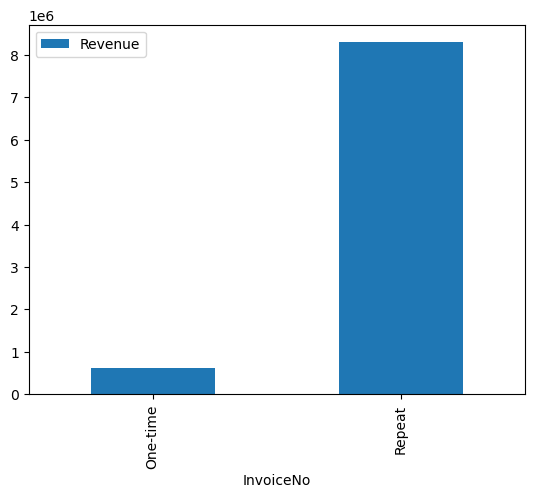

In [64]:
Segregation.plot.bar()

# Repeat customers contribute significantly more to revenue (~8.29M) compared to one-time customers (~0.61M), indicating that the business is heavily driven by repeat purchases. This highlights strong customer retention and suggests that maximizing repeat engagement is critical for revenue growth.

In [65]:
top_products = Online_retail.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

In [72]:
top_products.head()

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
Name: Revenue, dtype: float64

In [70]:
top_freq_products = Online_retail.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

In [73]:
top_freq_products.head()

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     55047
JUMBO BAG RED RETROSPOT               48478
WHITE HANGING HEART T-LIGHT HOLDER    37895
Name: Quantity, dtype: int64

In [74]:
country_revenue = Online_retail.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

In [76]:
country_revenue.head(10)

Country
United Kingdom    9003097.964
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209715.110
Australia          138521.310
Spain               61577.110
Switzerland         57089.900
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64

In [81]:
country_percent = ((country_revenue / country_revenue.sum()) * 100).round(2)

In [84]:
country_percent.head()

# strategy should focus on reducing market concentration risk, strengthening customer retention, and optimizing the product mix to create stable, scalable revenue growth.

Country
United Kingdom    84.58
Netherlands        2.68
EIRE               2.66
Germany            2.15
France             1.97
Name: Revenue, dtype: float64

<Axes: xlabel='Country'>

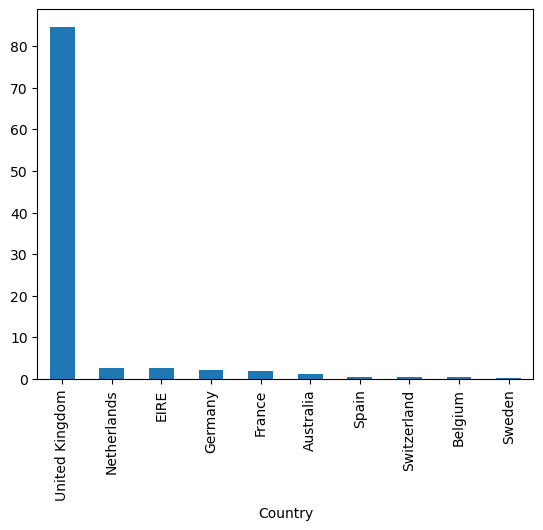

In [87]:
country_percent.head(10).plot.bar()